In [55]:
from ultralytics import YOLO
from roboflow import Roboflow
import shutil
from pathlib import Path

In [56]:

rf = Roboflow(api_key="038INb0Av0p6eo4CVxxx")
project = rf.workspace("marcuss-workspace").project("utility-poles-kcumt-nt0d2")
version = project.version(4)
dataset = version.download("yolo26")
                      

loading Roboflow workspace...
loading Roboflow project...


In [57]:


# Detection model — all 7 pole component classes (bounding boxes)
detect_model = YOLO("yolo26n.pt")

# Segmentation model — vegetation + guy_guard only (polygon masks)
seg_model = YOLO("yolo26n-seg.pt")

In [ ]:
# --- DETECTION MODEL ---
# Trains on all 7 classes: composite, guy_guard, insulator, street light,
# transformer, vegetation, wood — outputs bounding boxes.
detect_results = detect_model.train(
    data="Utility-Poles-4/data.yaml",
    epochs=100,
    imgsz=720,
    batch=16,
    device=0,          # set to "cpu" if no GPU
    optimizer="auto",  # uses MuSGD (YOLO26's new optimizer)
    lr0=0.001,
    patience=20,
    pretrained=True,
    cache=True,
    project="utility-pole-training",
    name="yolo26n-detect",
    save_period=10,
)

Ultralytics 8.4.19  Python-3.13.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Utility-Poles-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=720, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n-detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [ ]:
# --- SEGMENTATION DATASET DOWNLOAD ---
# Downloads the same project in yolov11 polygon format into a separate directory
# so the bbox labels in Utility-Poles-4/ are not overwritten.
# NOTE: Before running, verify in Roboflow that guy_guard and vegetation
# are annotated as drawn polygons (not just bounding rectangles).

rf = Roboflow(api_key="038INb0Av0p6eo4CVxxx")
project = rf.workspace("marcuss-workspace").project("utility-poles-kcumt-nt0d2")
version = project.version(4)
seg_dataset = version.download("yolov11", location="Utility-Poles-4-seg")  # polygon format — compatible with YOLO26-seg

In [ ]:
# --- FILTER TO 2-CLASS SEGMENTATION DATASET ---
# Keeps only guy_guard (class 1) and vegetation (class 5) from the full 7-class
# seg download and remaps them to class 0 and class 1 respectively.


# Map original class index -> new class index (drop everything else)
KEEP = {1: 0, 5: 1}   # guy_guard -> 0, vegetation -> 1

src_root = Path(seg_dataset.location)
dst_root = Path("Utility-Poles-4-seg-2cls")

for split in ["train", "valid", "test"]:
    (dst_root / split / "images").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "labels").mkdir(parents=True, exist_ok=True)
    lbl_dir = src_root / split / "labels"
    img_dir = src_root / split / "images"
    if not lbl_dir.exists():
        continue
    for lbl_path in lbl_dir.glob("*.txt"):
        new_lines = []
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls in KEEP:
                new_lines.append(f"{KEEP[cls]} " + " ".join(parts[1:]))
        if new_lines:
            (dst_root / split / "labels" / lbl_path.name).write_text("\n".join(new_lines))
            for ext in [".jpg", ".jpeg", ".png"]:
                img_src = img_dir / lbl_path.with_suffix(ext).name
                if img_src.exists():
                    shutil.copy(img_src, dst_root / split / "images" / img_src.name)
                    break

(dst_root / "data.yaml").write_text(
    f"train: ../{dst_root}/train/images\n"
    f"val: ../{dst_root}/valid/images\n"
    f"test: ../{dst_root}/test/images\n"
    f"nc: 2\n"
    f"names: ['guy_guard', 'vegetation']\n"
)
print(f"2-class seg dataset written to: {dst_root.resolve()}")

In [ ]:
# --- SEGMENTATION MODEL ---
# Trains on 2 classes only: guy_guard + vegetation — outputs polygon masks.
seg_results = seg_model.train(
    data="Utility-Poles-4-seg-2cls/data.yaml",
    epochs=100,
    imgsz=720,
    batch=16,
    device=0,          # set to "cpu" if no GPU
    optimizer="auto",
    lr0=0.001,
    patience=20,
    pretrained=True,
    cache=True,
    project="utility-pole-training",
    name="yolo26n-seg-veg-guy",
    save_period=10,
)

In [ ]:
# --- EXPORT BOTH MODELS FOR MOBILE ---
best_detect = YOLO("utility-pole-training/yolo26n-detect/weights/best.pt")
best_seg = YOLO("utility-pole-training/yolo26n-seg-veg-guy/weights/best.pt")

# Android (TFLite)
best_detect.export(format="tflite")
best_seg.export(format="tflite")

image 1/1 c:\Users\marcu\gridstorm-polepad-ai\model\utility-poles-3\test\images\Photo-Jun-06-2023-4-52-39-PM_jpg.rf.6db78f8c3c47f6d75fc24be888b8fdc7.jpg: 640x480 1 transformer, 16.1ms
Speed: 2.6ms preprocess, 16.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 c:\Users\marcu\gridstorm-polepad-ai\model\utility-poles-3\test\images\8fd4ff1f-2d9f-4768-8272-bb08994d5897_jpg.rf.f9ca80ace053f94b8ce966c2fe0a8ef6.jpg: 640x480 1 pole, 1 street light, 1 transformer, 16.1ms
Speed: 2.2ms preprocess, 16.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 c:\Users\marcu\gridstorm-polepad-ai\model\utility-poles-3\test\images\254f0cc0-bd58-49d3-b4ff-09baf21ceed3_jpg.rf.1af0feffd81de4b8d635dc2d6f753c28.jpg: 640x480 (no detections), 16.8ms
Speed: 2.6ms preprocess, 16.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)


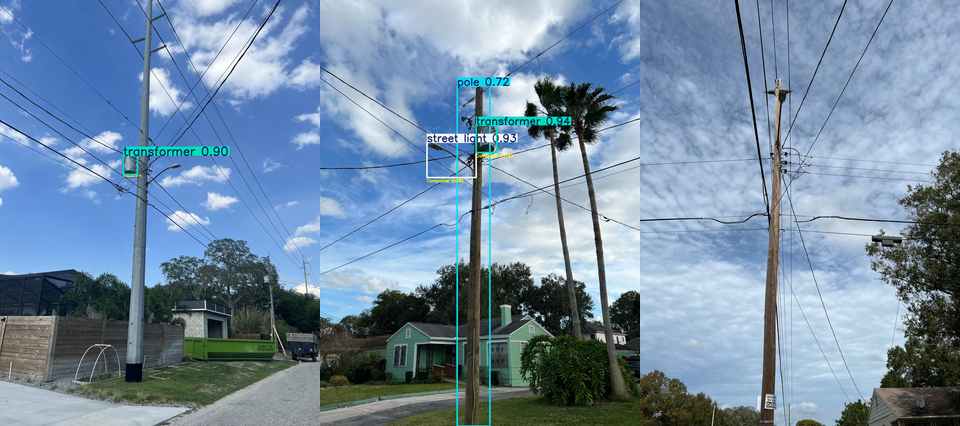

In [ ]:
import cv2
import io
import os
import random
import numpy as np
from IPython.display import display
from PIL import Image as PILImage

sample_img_path = "Utility-Poles-4/test/images"
all_images = [f for f in os.listdir(sample_img_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
sample_images = random.sample(all_images, min(3, len(all_images)))  # Show only three images

images_to_show = []
if sample_images:
    for img_name in sample_images:
        img_path = os.path.join(sample_img_path, img_name)
        orig_bgr = cv2.imread(img_path)
        results = detect_model(img_path, conf=0.35, iou=0.4, agnostic_nms=True)
        annotated_img = results[0].plot()  # BGR numpy array with YOLO boxes drawn

        # Skipping CLIP classification -- only show the annotated detection results
        # Convert annotated_img (BGR) to RGB for PIL
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        pil_image = PILImage.fromarray(annotated_img_rgb)
        images_to_show.append(pil_image)
        
    # Display side by side in a grid (up to 3 images in one row)
    cols = len(images_to_show)
    thumb_width = 320  # width for display
    thumb_height = int(images_to_show[0].height * (thumb_width / images_to_show[0].width))
    thumbs = [img.resize((thumb_width, thumb_height), PILImage.LANCZOS) for img in images_to_show]

    # Create a single wide image grid (1 row)
    grid_img = PILImage.new("RGB", (thumb_width * cols, thumb_height), color=(255, 255, 255))
    for i, img in enumerate(thumbs):
        grid_img.paste(img, (i * thumb_width, 0))
    display(grid_img)
else:
    print("No sample images found in the validation directory.")